# 🛍️ Consumer Shopping Behavior Analysis

## 📌 Project Overview

This project analyzes consumer shopping behavior to identify patterns in customer demographics, purchasing preferences, spending habits, payment methods, subscriptions, and shopping frequency.

The analysis uses Python and Pandas to explore the dataset and generate meaningful insights that can help understand customer behavior.

## 🎯 Objectives

* Analyze customer demographics and purchasing patterns
* Identify popular products and categories
* Understand customer spending behavior
* Analyze payment and shipping preferences
* Explore subscription behavior
* Identify patterns among different customer segments

## 🛠️ Tools & Technologies

* Python
* Pandas
* NumPy
* Matplotlib
* Seaborn
* Kaggle
* Jupyter Notebook


# 📊 About the Dataset

The dataset contains **3,900 customer purchase records** and **18 features** related to customer demographics, purchases, product categories, reviews, subscriptions, shipping, discounts, payment methods, and purchase frequency.

### Key Features

* **Customer ID** — Unique customer identifier
* **Age** — Customer age
* **Gender** — Customer gender
* **Item Purchased** — Product purchased
* **Category** — Product category
* **Purchase Amount (USD)** — Amount spent
* **Location** — Customer location
* **Season** — Season of purchase
* **Review Rating** — Customer review rating
* **Subscription Status** — Subscription information
* **Shipping Type** — Shipping method
* **Payment Method** — Payment method
* **Frequency of Purchases** — Purchase frequency


In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/iamsouravbanerjee/customer-shopping-trends-dataset/shopping_trends.csv
/kaggle/input/datasets/iamsouravbanerjee/customer-shopping-trends-dataset/shopping_trends_updated.csv


# 📥 Data Loading & Initial Exploration

In [2]:
import pandas as pd
df = pd.read_csv("/kaggle/input/datasets/iamsouravbanerjee/customer-shopping-trends-dataset/shopping_trends_updated.csv")
df.head()
#Load the shopping trends dataset and display the first 5 rows.

,Customer ID,Age,Gender,Item Purchased,Category,Purchase Amount (USD),Location,Size,Color,Season,Review Rating,Subscription Status,Shipping Type,Discount Applied,Promo Code Used,Previous Purchases,Payment Method,Frequency of Purchases
0,1,55,Male,Blouse,Clothing,53,Kentucky,L,Gray,Winter,3.1,Yes,Express,Yes,Yes,14,Venmo,Fortnightly
1,2,19,Male,Sweater,Clothing,64,Maine,L,Maroon,Winter,3.1,Yes,Express,Yes,Yes,2,Cash,Fortnightly
2,3,50,Male,Jeans,Clothing,73,Massachusetts,S,Maroon,Spring,3.1,Yes,Free Shipping,Yes,Yes,23,Credit Card,Weekly
3,4,21,Male,Sandals,Footwear,90,Rhode Island,M,Maroon,Spring,3.5,Yes,Next Day Air,Yes,Yes,49,PayPal,Weekly
4,5,45,Male,Blouse,Clothing,49,Oregon,M,Turquoise,Spring,2.7,Yes,Free Shipping,Yes,Yes,31,PayPal,Annually


In [3]:
df.describe()
# Statistical summary of numerical features

,Customer ID,Age,Purchase Amount (USD),Review Rating,Previous Purchases
count,3900.000000,3900.000000,3900.000000,3900.000000,3900.000000
mean,1950.500000,44.068462,59.764359,3.749949,25.351538
std,1125.977353,15.207589,23.685392,0.716223,14.447125
min,1.000000,18.000000,20.000000,2.500000,1.000000
25%,975.750000,31.000000,39.000000,3.100000,13.000000
50%,1950.500000,44.000000,60.000000,3.700000,25.000000
75%,2925.250000,57.000000,81.000000,4.400000,38.000000
max,3900.000000,70.000000,100.000000,5.000000,50.000000


In [4]:
df[(df['Age'] > 20) & (df['Age'] < 25)]
#Filter the dataset to view records for customers between the ages of 21 and 24(young gen)

,Customer ID,Age,Gender,Item Purchased,Category,Purchase Amount (USD),Location,Size,Color,Season,Review Rating,Subscription Status,Shipping Type,Discount Applied,Promo Code Used,Previous Purchases,Payment Method,Frequency of Purchases
3,4,21,Male,Sandals,Footwear,90,Rhode Island,M,Maroon,Spring,3.5,Yes,Next Day Air,Yes,Yes,49,PayPal,Weekly
20,21,21,Male,Pants,Clothing,51,Louisiana,M,Black,Winter,2.8,Yes,Express,Yes,Yes,50,Cash,Every 3 Months
57,58,21,Male,Coat,Outerwear,64,West Virginia,M,White,Summer,4.4,Yes,Store Pickup,Yes,Yes,17,Debit Card,Fortnightly
70,71,22,Male,Belt,Accessories,29,Alabama,M,Magenta,Fall,4.2,Yes,Express,Yes,Yes,32,Debit Card,Every 3 Months
77,78,22,Male,Dress,Clothing,53,Delaware,L,Gold,Summer,3.3,Yes,Next Day Air,Yes,Yes,36,Debit Card,Fortnightly
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3770,3771,23,Female,Pants,Clothing,42,Montana,L,Black,Summer,4.0,No,Store Pickup,No,No,34,Bank Transfer,Weekly
3771,3772,21,Female,T-shirt,Clothing,86,Oklahoma,M,Red,Winter,2.6,No,Express,No,No,28,Venmo,Bi-Weekly
3830,3831,22,Female,Hat,Accessories,27,Pennsylvania,M,Indigo,Summer,3.0,No,2-Day Shipping,No,No,33,Bank Transfer,Every 3 Months
3848,3849,22,Female,Jewelry,Accessories,60,New Hampshire,M,Magenta,Winter,3.0,No,Next Day Air,No,No,39,Cash,Every 3 Months


In [5]:
# Define the segment once
young_adults = df[(df["Age"] >= 20) & (df["Age"] <= 25)]

# Extract insights using the new variable
most_frequent_item = young_adults["Item Purchased"].value_counts().idxmax()
least_frequent_item = young_adults["Item Purchased"].value_counts().idxmin()
avg_purchase = young_adults['Purchase Amount (USD)'].mean()
top_payment = young_adults["Payment Method"].value_counts().idxmax()

print(f"Top Item: {most_frequent_item} | Least Item: {least_frequent_item}")
print(f"Avg Spent: ${avg_purchase:.2f} | Top Payment: {top_payment}")

Top Item: Sweater | Least Item: Shoes
Avg Spent: $60.69 | Top Payment: Cash


In [6]:
df[df['Gender'] == 'Female']["Item Purchased"].value_counts().idxmin()
#What is the least popular item purchased by female customers?

'Jeans'

In [7]:
df["Location"].value_counts().idxmax()
### Geographic Purchasing Trends
##To determine where our core customer base resides, we will identify the state with the highest transaction volume.

'Montana'

**Insight:** Montana leads the US in total purchases, suggesting regional marketing campaigns there are highly effective.

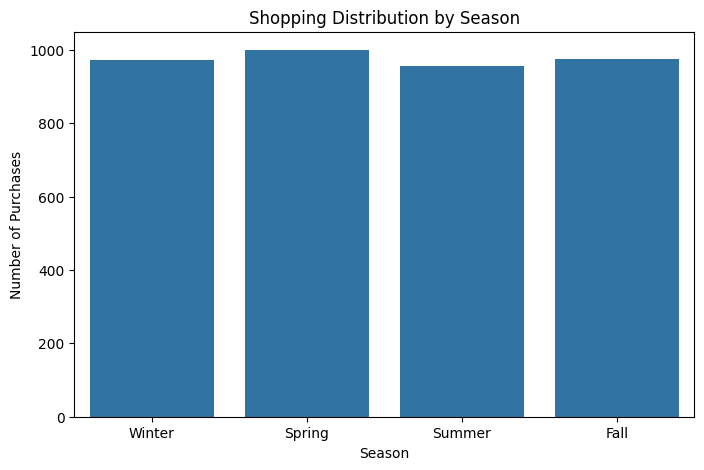

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))
sns.countplot(data=df, x="Season")
plt.title("Shopping Distribution by Season")
plt.xlabel("Season")
plt.ylabel("Number of Purchases")
plt.show()

#Spring has the highest number of purchases among the four seasons in this dataset.

In [9]:
df.groupby("Item Purchased")["Review Rating"].mean().sort_values(ascending=False).head(1)
#Which purchased item has the highest average review rating?  

Item Purchased
Gloves    3.864286
Name: Review Rating, dtype: float64

In [10]:
df["Shipping Type"].value_counts().idxmin()
#What is the least commonly used shipping type?

'2-Day Shipping'

In [11]:
df["Subscription Status"].value_counts()
#How many customers have an active subscription versus no subscription?  

Subscription Status
No     2847
Yes    1053
Name: count, dtype: int64

In [12]:
df['Previous Purchases'].value_counts().idxmax()
#What is the most frequent number of previous purchases made by a customer?

np.int64(31)

In [13]:
df[(df["Age"] >= 20) & (df["Age"] <= 25)]["Payment Method"].value_counts().idxmax()
#What is the most popular payment method among customers aged 20 to 25?(young gen)

'Cash'

In [14]:
df[df["Age"] > 35]["Payment Method"].value_counts().idxmax()
#What is the most popular payment method among customers older than 35?

'PayPal'

# 📊 Exploratory Data Analysis

This section explores customer demographics, purchasing patterns, spending behavior, and shopping preferences through visualizations.

## 👥 Customer Age Distribution

<Axes: xlabel='Age', ylabel='Count'>

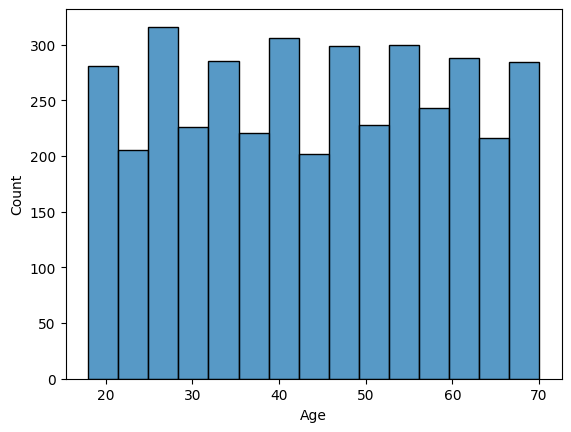

In [15]:
sns.histplot(data=df, x="Age", bins=15)


<Axes: xlabel='Gender', ylabel='count'>

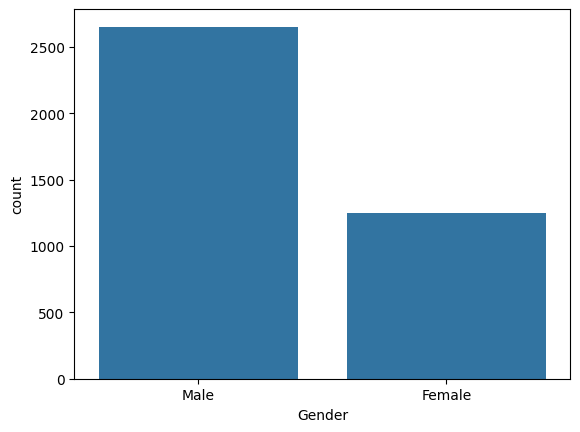

In [16]:
sns.countplot(data=df, x="Gender")

<Axes: xlabel='Category', ylabel='count'>

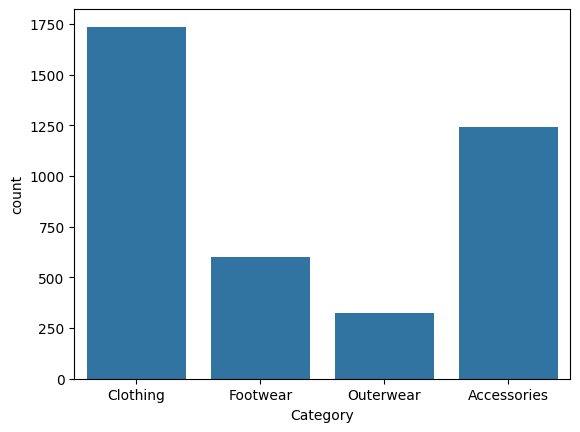

In [17]:
sns.countplot(data=df, x="Category")

<Axes: xlabel='Season', ylabel='count'>

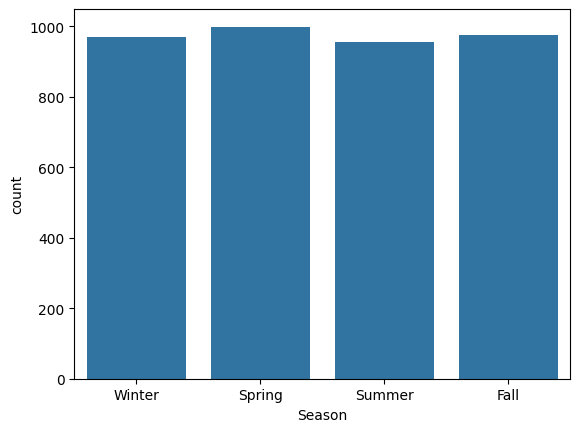

In [18]:
sns.countplot(data=df, x="Season")

<Axes: xlabel='Purchase Amount (USD)', ylabel='Count'>

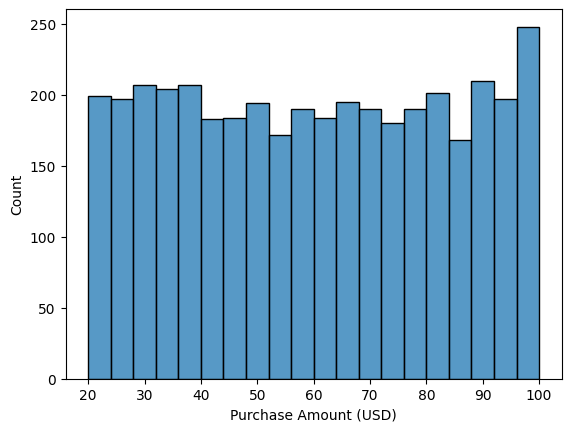

In [19]:
sns.histplot(data=df, x="Purchase Amount (USD)", bins=20)

<Axes: xlabel='Payment Method', ylabel='count'>

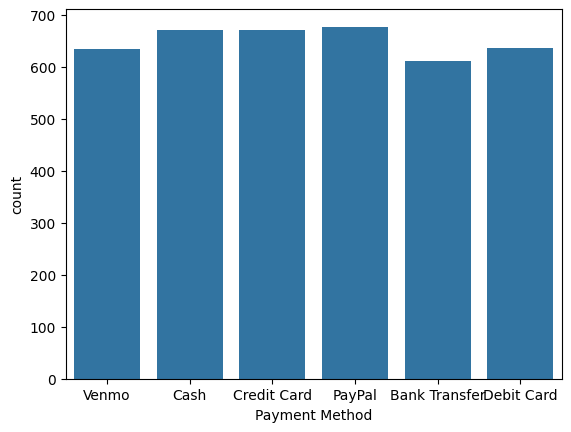

In [20]:
sns.countplot(data=df, x="Payment Method")

<Axes: xlabel='Subscription Status', ylabel='count'>

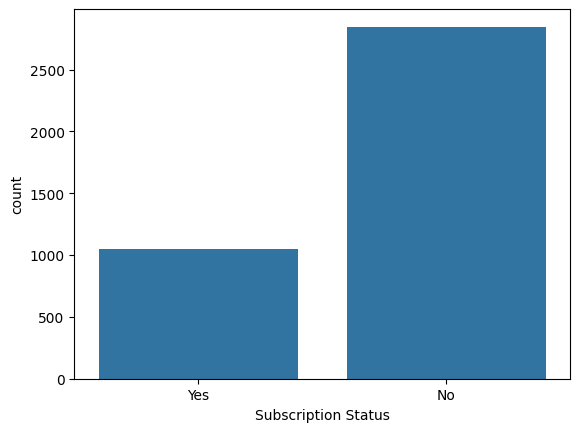

In [21]:
sns.countplot(data=df, x="Subscription Status")

<Axes: xlabel='Category', ylabel='Purchase Amount (USD)'>

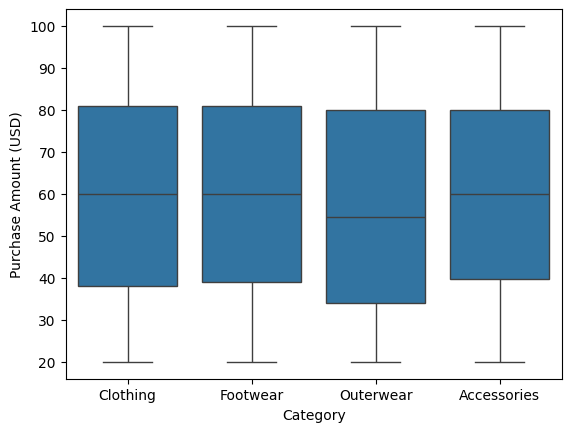

In [22]:
sns.boxplot(data=df, x="Category", y="Purchase Amount (USD)")

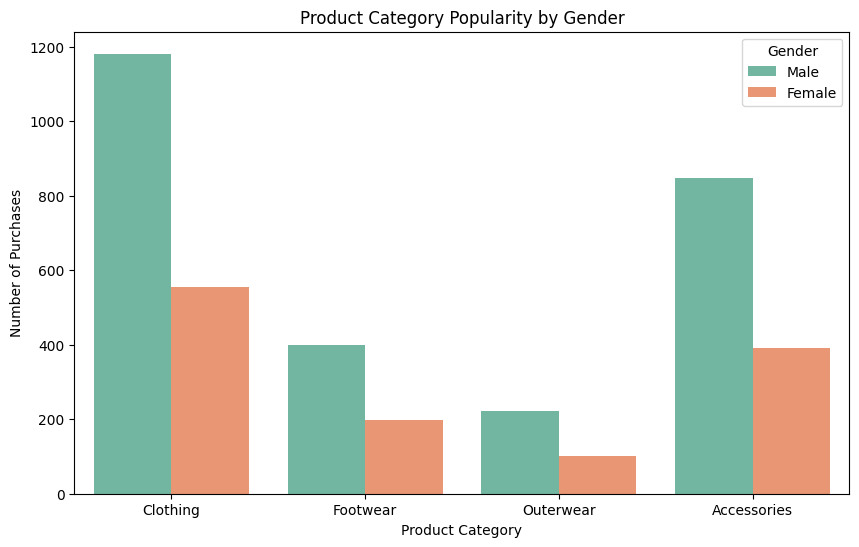

In [23]:
plt.figure(figsize=(10,6))
sns.countplot(data=df, x="Category", hue="Gender", palette="Set2")
plt.title("Product Category Popularity by Gender")
plt.xlabel("Product Category")
plt.ylabel("Number of Purchases")
plt.show()

Customer Segment Profiles:
------------------------------
         Previous Purchases  Review Rating  Purchase Amount (USD)  \
Cluster                                                             
0                     38.95           3.97                  79.65   
1                     23.29           4.36                  38.22   
2                     27.57           3.04                  43.54   
3                     11.45           3.72                  79.35   

         Customer Count  
Cluster                  
0                   947  
1                   947  
2                  1053  
3                   953  


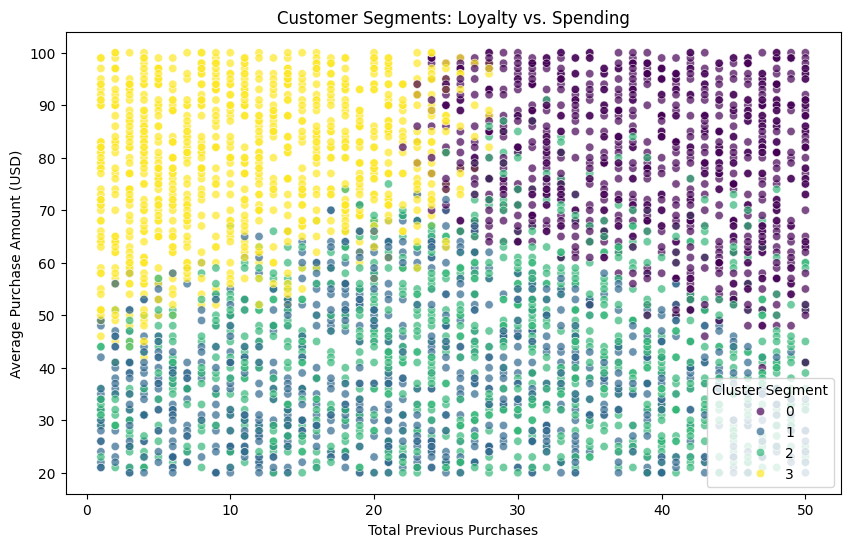

In [24]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# 1. Select the features for segmentation
# Focusing on loyalty and lifetime value: Previous Purchases, Review Rating, and Purchase Amount
features = ['Previous Purchases', 'Review Rating', 'Purchase Amount (USD)']
X = df[features]

# 2. Scale the data
# Standardizing ensures that features with larger ranges (like Purchase Amount) 
# don't dominate features with smaller ranges (like Review Rating).
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 3. Apply K-Means Clustering
# We will segment the customers into 4 distinct groups
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
df['Cluster'] = kmeans.fit_predict(X_scaled)

# 4. Analyze the Clusters
# Calculate the average values for each cluster to understand their distinct profiles
cluster_summary = df.groupby('Cluster')[features].mean().round(2)
cluster_summary['Customer Count'] = df['Cluster'].value_counts()

print("Customer Segment Profiles:")
print("-" * 30)
print(cluster_summary)

# 5. Visualize the Segments
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=df, 
    x='Previous Purchases', 
    y='Purchase Amount (USD)', 
    hue='Cluster', 
    palette='viridis', 
    alpha=0.7
)
plt.title('Customer Segments: Loyalty vs. Spending')
plt.xlabel('Total Previous Purchases')
plt.ylabel('Average Purchase Amount (USD)')
plt.legend(title='Cluster Segment')
plt.show()

In [25]:
# Inspect the summary table from your previous run
# Assign meaningful persona names based on the resulting values
cluster_labels = {
    0: 'High-Value Loyalists',   # High spend, high previous purchases
    1: 'Satisfied Occasionals',  # Moderate spend, high rating, low purchases
    2: 'At-Risk Buyers',         # Low rating, low-to-moderate purchases
    3: 'Discount/Bargain Seekers'# Low spend, moderate purchases
}

df['Segment_Name'] = df['Cluster'].map(cluster_labels)
print(df[['Customer ID', 'Segment_Name', 'Previous Purchases', 'Purchase Amount (USD)']].head())

   Customer ID              Segment_Name  Previous Purchases  \
0            1            At-Risk Buyers                  14   
1            2  Discount/Bargain Seekers                   2   
2            3  Discount/Bargain Seekers                  23   
3            4      High-Value Loyalists                  49   
4            5            At-Risk Buyers                  31   

   Purchase Amount (USD)  
0                     53  
1                     64  
2                     73  
3                     90  
4                     49  


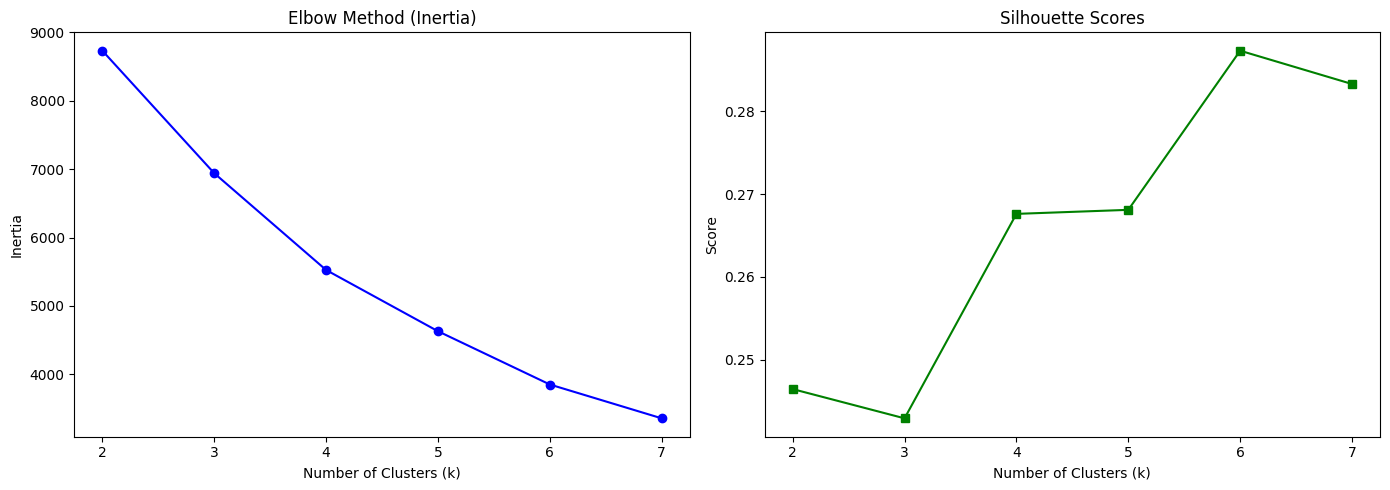

In [26]:
from sklearn.metrics import silhouette_score

inertia = []
silhouette_scores = []
k_range = range(2, 8)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertia.append(km.inertia_)
    silhouette_scores.append(silhouette_score(X_scaled, km.labels_))

# Plot Elbow and Silhouette curves
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

ax[0].plot(k_range, inertia, marker='o', color='b')
ax[0].set_title('Elbow Method (Inertia)')
ax[0].set_xlabel('Number of Clusters (k)')
ax[0].set_ylabel('Inertia')

ax[1].plot(k_range, silhouette_scores, marker='s', color='g')
ax[1].set_title('Silhouette Scores')
ax[1].set_xlabel('Number of Clusters (k)')
ax[1].set_ylabel('Score')

plt.tight_layout()
plt.show()

# 🏁 Conclusion & Strategic Recommendations

This project successfully transformed raw customer transaction data into actionable business intelligence through Exploratory Data Analysis (EDA) and K-Means clustering.

### Key Analytical Outcomes
*   **Demographic & Seasonal Trends:** Identified distinct product and payment preferences across age groups, such as young adults preferring Cash and Sweaters, and established Spring as the peak shopping season[cite: 1, 2].
*   **Customer Segmentation:** Applied K-Means clustering to move beyond basic demographics, categorizing the customer base into distinct behavioral personas based on lifetime value and loyalty (e.g., High-Value Loyalists, At-Risk Buyers).
*   **Growth Opportunities:** Revealed a significant gap in subscription adoption—the vast majority of the 3,900 customers do not have active subscriptions despite high average purchase counts[cite: 1, 2], representing a prime opportunity for recurring revenue growth.

### Business Strategy & Next Steps
By understanding these distinct customer profiles, the business can shift from generic marketing to targeted, data-driven campaigns. Future initiatives should focus on:
1. Developing personalized subscription incentives specifically targeted at "High-Value Loyalists."
2. Deploying targeted re-engagement campaigns for "At-Risk Buyers."
3. Building predictive models (e.g., XGBoost) to forecast individual customer spending and optimize inventory for seasonal peaks.